# MobileNetV3 Training on 100-Driver

This notebook adapts your MobileNetV3 State Farm training setup to the **100-driver** dataset using the repo's **txt split files**.

It uses:
- `*_train.txt` / `*_val.txt` split files
- image paths built as `IMG_ROOT / relative_path`
- labels from column 3 of each split file
- MobileNetV3-Large transfer learning
- AMP, early stopping, checkpointing, evaluation, and plots


## 0) Install packages

Run these only if needed, then restart the kernel.


In [30]:
# %pip install -U pip setuptools wheel
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130
# %pip install numpy pandas scikit-learn pillow tqdm matplotlib

## 1) Imports

In [31]:
import os
import json
import math
import random
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFile

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

ImageFile.LOAD_TRUNCATED_IMAGES = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## 2) Config

In [ ]:
DATA_ROOT = Path(r"../Datasets/100-driver")
SETTING = "Traditional-setting"
TIME_OF_DAY = "Day"
CAMERA = "Cam1"
SPLIT_PREFIX = None   # e.g. "D1" for Cam1, or leave None to auto-discover
IMG_ROOT_OVERRIDE = r"../Datasets/100-driver/Day/Cam1"  # set to exact image root if needed

@dataclass
class TrainConfig:
    epochs: int = 25
    lr: float = 2e-4
    weight_decay: float = 1e-2
    label_smoothing: float = 0.02
    grad_clip: float = 1.0
    patience: int = 8
    min_delta: float = 0.002
    batch_size: int = 128
    num_workers: int = 8
    img_size: int = 256
    unfreeze_last_n_blocks: int = 4
    seed: int = 42
    out_dir: Path = Path("./checkpoints")
    best_name: str = "mobilenetv3_100driver_best.pt"

cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
cfg

TrainConfig(epochs=25, lr=0.0003, weight_decay=0.01, label_smoothing=0.02, grad_clip=1.0, patience=8, min_delta=0.002, batch_size=128, num_workers=8, img_size=512, unfreeze_last_n_blocks=4, seed=42, out_dir=PosixPath('checkpoints'), best_name='mobilenetv3_100driver_best.pt')

## 3) Utility functions

In [33]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected, falling back to CPU.")

def parse_split_file(txt_path: Path):
    records = []
    with open(txt_path, "r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                print(f"Skipping malformed line {line_no} in {txt_path}: {line!r}")
                continue

            sample_id = parts[0]
            rel_path = parts[1]
            label = int(parts[2])
            records.append({"sample_id": sample_id, "rel_path": rel_path, "label": label})
    return records

def infer_class_names(records):
    names_by_label = defaultdict(list)
    for rec in records:
        rel = Path(rec["rel_path"])
        folder_name = rel.parent.name if rel.parent.name else f"class_{rec['label']}"
        names_by_label[rec["label"]].append(folder_name)

    max_label = max(r["label"] for r in records)
    ordered_names = []
    for i in range(max_label + 1):
        if i in names_by_label:
            ordered_names.append(Counter(names_by_label[i]).most_common(1)[0][0])
        else:
            ordered_names.append(f"class_{i}")
    return ordered_names

def resolve_split_root(dataset_root: Path, setting: str, time_of_day: str, camera: str) -> Path:
    candidates = [
        dataset_root / "data-splits" / "data-splits" / setting / time_of_day / camera,
        dataset_root / "data-splits" / setting / time_of_day / camera,
    ]
    for cand in candidates:
        if cand.exists():
            return cand
    raise FileNotFoundError("Could not find split folder. Checked:\n" + "\n".join(str(c) for c in candidates))

def resolve_split_files(split_root: Path, split_prefix=None):
    if split_prefix:
        train_txt = split_root / f"{split_prefix}_train.txt"
        val_txt = split_root / f"{split_prefix}_val.txt"
        test_txt = split_root / f"{split_prefix}_test.txt"
        if not train_txt.exists() or not val_txt.exists():
            raise FileNotFoundError(f"Missing expected split files for prefix {split_prefix} in {split_root}")
        return train_txt, val_txt, test_txt if test_txt.exists() else None

    train_candidates = sorted(split_root.glob("*_train.txt"))
    val_candidates = sorted(split_root.glob("*_val.txt"))
    test_candidates = sorted(split_root.glob("*_test.txt"))

    if len(train_candidates) != 1 or len(val_candidates) != 1:
        raise RuntimeError(
            f"Could not auto-resolve split files in {split_root}. "
            f"Found train={train_candidates}, val={val_candidates}. "
            "Set SPLIT_PREFIX explicitly."
        )

    train_txt = train_candidates[0]
    val_txt = val_candidates[0]
    test_txt = test_candidates[0] if len(test_candidates) == 1 else None
    return train_txt, val_txt, test_txt

def resolve_img_root(dataset_root: Path, time_of_day: str, camera: str, sample_rel_path: str, img_root_override=None):
    if img_root_override:
        cand = Path(img_root_override)
        if (cand / sample_rel_path).exists():
            return cand
        raise FileNotFoundError(f"IMG_ROOT_OVERRIDE does not contain sample image:\n{cand / sample_rel_path}")

    candidates = [
        dataset_root / time_of_day / camera,
        dataset_root / time_of_day.lower() / camera.lower(),
        dataset_root / time_of_day / camera.lower(),
        dataset_root / time_of_day.lower() / camera,
        dataset_root / "data" / "100-driver" / time_of_day / camera,
        dataset_root / "data" / "100-driver" / time_of_day.lower() / camera.lower(),
        dataset_root / "data" / "100-driver" / "Day_RGB" / camera,
        dataset_root / "data" / "100-driver" / "Night_RGB" / camera,
        dataset_root / "Day_RGB" / camera,
        dataset_root / "Night_RGB" / camera,
    ]
    checked = []
    for cand in candidates:
        checked.append(str(cand / sample_rel_path))
        if (cand / sample_rel_path).exists():
            print("Resolved IMG_ROOT:", cand)
            return cand

    raise FileNotFoundError("Could not resolve image root automatically.\nChecked:\n" + "\n".join(checked))

seed_everything(cfg.seed)
cuda_sanity_check()

torch: 2.9.1+cu130
torchvision: 0.24.1+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: 0.01653379574418068


## 4) Resolve split files and image root

In [34]:
split_root = resolve_split_root(DATA_ROOT, SETTING, TIME_OF_DAY, CAMERA)
TRAIN_TXT, VAL_TXT, TEST_TXT = resolve_split_files(split_root, SPLIT_PREFIX)

print("Train split:", TRAIN_TXT)
print("Val split:  ", VAL_TXT)
print("Test split: ", TEST_TXT)

train_records = parse_split_file(TRAIN_TXT)
val_records = parse_split_file(VAL_TXT)

if len(train_records) == 0 or len(val_records) == 0:
    raise RuntimeError("Train or val split parsed zero records.")

sample_rel_path = train_records[0]["rel_path"]
IMG_ROOT = resolve_img_root(DATA_ROOT, TIME_OF_DAY, CAMERA, sample_rel_path, IMG_ROOT_OVERRIDE)

labels = sorted({r["label"] for r in train_records} | {r["label"] for r in val_records})
NUM_CLASSES = max(labels) + 1
CLASS_NAMES = infer_class_names(train_records + val_records)

print("IMG_ROOT:", IMG_ROOT)
print("Sample image exists:", (IMG_ROOT / sample_rel_path).exists())
print("Train images:", len(train_records))
print("Val images:  ", len(val_records))
print("Labels found:", labels)
print("Num classes:", NUM_CLASSES)
print("First few class names:", CLASS_NAMES[:min(10, len(CLASS_NAMES))])

Train split: ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_train.txt
Val split:   ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_val.txt
Test split:  ../Datasets/100-driver/data-splits/data-splits/Traditional-setting/Day/Cam1/D1_test.txt
IMG_ROOT: ../Datasets/100-driver/Day/Cam1
Sample image exists: True
Train images: 45388
Val images:   4334
Labels found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]
Num classes: 22
First few class names: ['C1_Drive_Safe', 'C2_Sleep', 'C3_Yawning', 'C4_Talk_Left', 'C5_Talk_Right', 'C6_Text_Left', 'C7_Text_Right', 'C8_Make_Up', 'C9_Look_Left', 'C10_Look_Right']


## 5) Transforms

In [ ]:
weights = MobileNet_V3_Large_Weights.DEFAULT
preprocess = weights.transforms()
mean = getattr(preprocess, "mean", None) or weights.meta.get("mean", [0.485, 0.456, 0.406])
std = getattr(preprocess, "std", None) or weights.meta.get("std", [0.229, 0.224, 0.225])

train_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.RandomAffine(
        degrees=6,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=InterpolationMode.BILINEAR
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    transforms.RandomErasing(p=0.10, scale=(0.02, 0.08)),
])

val_tfms = transforms.Compose([
    transforms.Resize((cfg.img_size, cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

print("mean:", mean)
print("std:", std)
print("img_size:", cfg.img_size)

mean: [0.485, 0.456, 0.406]
std: [0.229, 0.224, 0.225]
img_size: 512


## 6) Dataset and loaders

In [36]:
class TxtSplitImageDataset(Dataset):
    def __init__(self, records, img_root: Path, transform=None, cache_images=False):
        self.records = list(records)
        self.img_root = Path(img_root)
        self.transform = transform
        self.cache_images = cache_images
        self._cache = {}

    def __len__(self):
        return len(self.records)

    def _load_image(self, idx):
        if self.cache_images and idx in self._cache:
            return self._cache[idx].copy()

        img_path = self.img_root / self.records[idx]["rel_path"]
        img = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[idx] = img.copy()

        return img

    def __getitem__(self, idx):
        rec = self.records[idx]
        img = self._load_image(idx)
        x = self.transform(img) if self.transform else transforms.ToTensor()(img)
        y = int(rec["label"])
        return x, y

train_ds = TxtSplitImageDataset(train_records, img_root=IMG_ROOT, transform=train_tfms, cache_images=False)
val_ds = TxtSplitImageDataset(val_records, img_root=IMG_ROOT, transform=val_tfms, cache_images=False)

pin_memory = (device.type == "cuda")
train_loader = DataLoader(
    train_ds,
    batch_size=cfg.batch_size,
    shuffle=True,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)
val_loader = DataLoader(
    val_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    pin_memory=pin_memory,
    persistent_workers=(cfg.num_workers > 0),
)

print("Train dataset size:", len(train_ds))
print("Val dataset size:  ", len(val_ds))

t0 = time.time()
xb, yb = next(iter(train_loader))
print("Got batch:", xb.shape, yb.shape, "in", round(time.time() - t0, 2), "sec")

Train dataset size: 45388
Val dataset size:   4334
Got batch: torch.Size([128, 3, 512, 512]) torch.Size([128]) in 5.54 sec


## 7) Model

In [37]:
def build_model(num_classes: int, device: torch.device, unfreeze_last_n_blocks: int):
    weights = MobileNet_V3_Large_Weights.DEFAULT
    model = mobilenet_v3_large(weights=weights)

    last_channel = model.classifier[-1].in_features
    model.classifier[-1] = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(last_channel, 1280),
        nn.Hardswish(),
        nn.Dropout(p=0.6),
        nn.Linear(1280, num_classes),
    )

    for p in model.parameters():
        p.requires_grad = False

    for p in model.classifier.parameters():
        p.requires_grad = True

    feature_blocks = list(model.features.children())
    for block in feature_blocks[-unfreeze_last_n_blocks:]:
        for p in block.parameters():
            p.requires_grad = True

    model = model.to(device)

    if device.type == "cuda":
        torch.backends.cudnn.benchmark = True
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
        try:
            torch.set_float32_matmul_precision("high")
        except Exception:
            pass

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
    print("Unfroze last", unfreeze_last_n_blocks, "feature blocks + classifier.")

    return model

model = build_model(NUM_CLASSES, device, cfg.unfreeze_last_n_blocks)

Trainable params: 5,077,406 / 5,869,894 (86.50%)
Unfroze last 4 feature blocks + classifier.


## 8) Training utilities

In [38]:
criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

feature_params = []
head_params = []
for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if name.startswith("classifier"):
        head_params.append(p)
    else:
        feature_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": feature_params, "lr": cfg.lr * 0.2},
        {"params": head_params, "lr": cfg.lr},
    ],
    weight_decay=cfg.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
)

scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

def get_lrs(opt):
    return [pg["lr"] for pg in opt.param_groups]

def run_one_epoch(model, loader, train: bool):
    model.train(train)
    all_y = []
    all_p = []
    total_loss = 0.0

    pbar = tqdm(loader, desc="train" if train else "val", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()

                if cfg.grad_clip is not None and cfg.grad_clip > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

                scaler.step(optimizer)
                scaler.update()

        total_loss += float(loss.item()) * xb.size(0)

        preds = logits.argmax(dim=1)
        all_y.append(yb.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())
        pbar.set_postfix(loss=float(loss.item()))

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, acc, f1

def save_checkpoint(path: Path, model, meta: dict):
    torch.save(model.state_dict(), path)
    with open(path.with_suffix(".json"), "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)

best_val_f1 = -1.0
best_epoch = -1
bad_epochs = 0
history = []

## 9) Train

In [39]:
best_path = cfg.out_dir / cfg.best_name

print("Starting training...")
for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    train_loss, train_acc, train_f1 = run_one_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_one_epoch(model, val_loader, train=False)

    before = get_lrs(optimizer)
    scheduler.step(val_f1)
    after = get_lrs(optimizer)

    if after != before:
        print("LR reduced from", before, "to", after)

    dt = time.time() - t0
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "seconds": dt,
        "lr_backbone": optimizer.param_groups[0]["lr"],
        "lr_head": optimizer.param_groups[1]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
        f"{dt:.1f}s"
    )

    if val_f1 > best_val_f1 + cfg.min_delta:
        best_val_f1 = val_f1
        best_epoch = epoch
        bad_epochs = 0

        meta = {
            "class_names": CLASS_NAMES,
            "num_classes": NUM_CLASSES,
            "img_size": cfg.img_size,
            "mean": mean,
            "std": std,
            "time_of_day": TIME_OF_DAY,
            "camera": CAMERA,
            "setting": SETTING,
            "train_split": str(TRAIN_TXT),
            "val_split": str(VAL_TXT),
            "img_root": str(IMG_ROOT),
            "torch_version": str(torch.__version__),
        }
        save_checkpoint(best_path, model, meta)
        print("Saved best checkpoint:", best_path)
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.patience:
            print(f"Early stopping: no val_f1 improvement for {cfg.patience} epochs.")
            break

print("Best epoch:", best_epoch, "Best val f1:", best_val_f1)

Starting training...


Epoch 01/25 | train loss 1.3289 acc 0.6181 f1 0.6200 | val loss 1.1505 acc 0.6800 f1 0.6560 | 231.8s
Saved best checkpoint: checkpoints/mobilenetv3_100driver_best.pt


Epoch 02/25 | train loss 0.4542 acc 0.9152 f1 0.9136 | val loss 1.1761 acc 0.7063 f1 0.6888 | 206.6s
Saved best checkpoint: checkpoints/mobilenetv3_100driver_best.pt


Epoch 03/25 | train loss 0.3245 acc 0.9611 f1 0.9610 | val loss 1.1211 acc 0.7035 f1 0.6837 | 206.5s


Epoch 04/25 | train loss 0.2719 acc 0.9780 f1 0.9782 | val loss 1.3236 acc 0.6569 f1 0.6503 | 206.6s


...

Epoch 09/25 | train loss 0.1950 acc 0.9943 f1 0.9943 | val loss 1.1615 acc 0.7146 f1 0.7036 | 206.0s


Epoch 10/25 | train loss 0.1909 acc 0.9949 f1 0.9951 | val loss 1.1453 acc 0.7183 f1 0.7043 | 206.9s


LR reduced from [2.9999999999999997e-05, 0.00015] to [1.4999999999999999e-05, 7.5e-05]
Epoch 11/25 | train loss 0.1873 acc 0.9958 f1 0.9959 | val loss 1.1586 acc 0.7162 f1 0.6998 | 207.7s


Epoch 12/25 | train loss 0.1829 acc 0.9968 f1 0.9969 | val loss 1.1713 acc 0.7123 f1 0.7027 | 210.1s


Epoch 13/25 | train loss 0.1821 acc 0.9965 f1 0.9966 | val loss 1.2447 acc 0.6957 f1 0.6943 | 210.6s
Early stopping: no val_f1 improvement for 8 epochs.
Best epoch: 5 Best val f1: 0.7098403008912598


## 10) Training results

In [40]:
hist = pd.DataFrame(history)
hist.to_csv(cfg.out_dir / "history.csv", index=False)
hist.tail()

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,seconds,lr_backbone,lr_head
8,9,0.195022,0.994272,0.994347,1.161513,0.714582,0.703619,206.019364,0.000030,0.000150
9,10,0.190907,0.994933,0.995118,1.145253,0.718274,0.704275,206.949030,0.000030,0.000150
10,11,0.187287,0.995770,0.995868,1.158551,0.716198,0.699753,207.711048,0.000015,0.000075
11,12,0.182907,0.996849,0.996857,1.171275,0.712275,0.702654,210.081664,0.000015,0.000075
12,13,0.182112,0.996541,0.996626,1.244691,0.695662,0.694259,210.603447,0.000015,0.000075


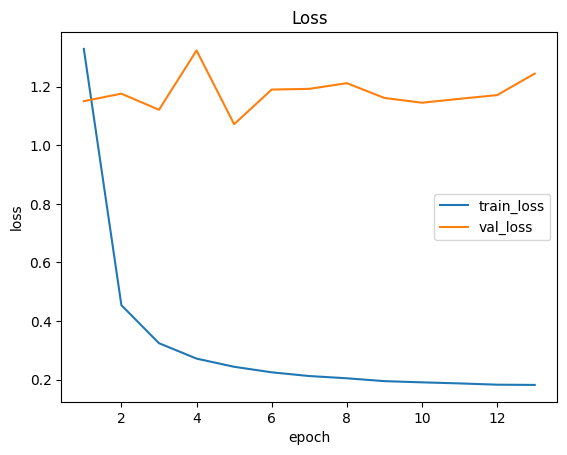

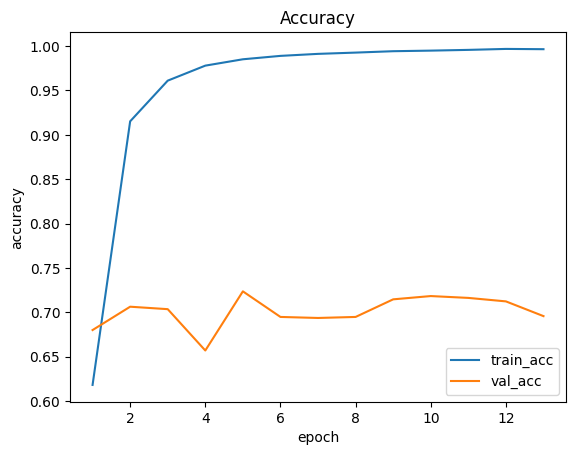

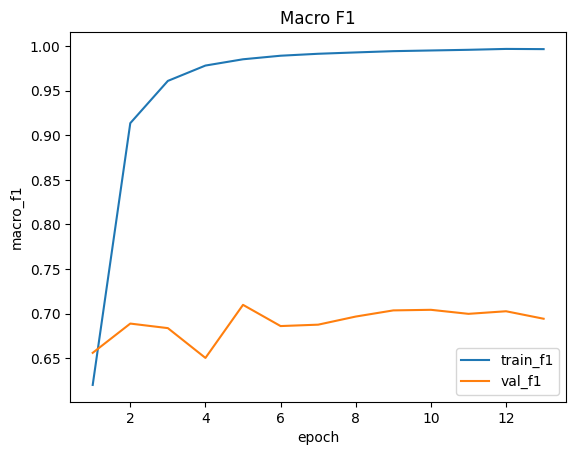

In [41]:
if not hist.empty:
    plt.figure()
    plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
    plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
    plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy")
    plt.show()

    plt.figure()
    plt.plot(hist["epoch"], hist["train_f1"], label="train_f1")
    plt.plot(hist["epoch"], hist["val_f1"], label="val_f1")
    plt.legend()
    plt.xlabel("epoch")
    plt.ylabel("macro_f1")
    plt.title("Macro F1")
    plt.show()

## 11) Best-model evaluation

val eval: 100%|██████████| 34/34 [00:22<00:00,  1.52it/s]


Accuracy: 0.7235809875403784
Macro F1: 0.7100449151665829

Classification report:

                          precision    recall  f1-score   support

           C1_Drive_Safe     0.4343    0.5312    0.4779       224
                C2_Sleep     0.9130    0.4078    0.5638       309
              C3_Yawning     0.9075    0.8579    0.8820       183
            C4_Talk_Left     1.0000    0.4483    0.6190       261
           C5_Talk_Right     0.9948    0.8756    0.9314       217
            C6_Text_Left     0.8607    0.7241    0.7865       145
           C7_Text_Right     0.9023    0.8546    0.8778       227
              C8_Make_Up     0.5856    0.7910    0.6730       268
            C9_Look_Left     0.8468    0.7769    0.8103       242
          C10_Look_Right     0.4930    0.7413    0.5922       143
             C11_Look_Up     0.9612    0.8493    0.9018       146
           C12_Look_Down     0.5177    0.7192    0.6021       203
          C13_Smoke_Left     0.9548    0.8577    0.9036   

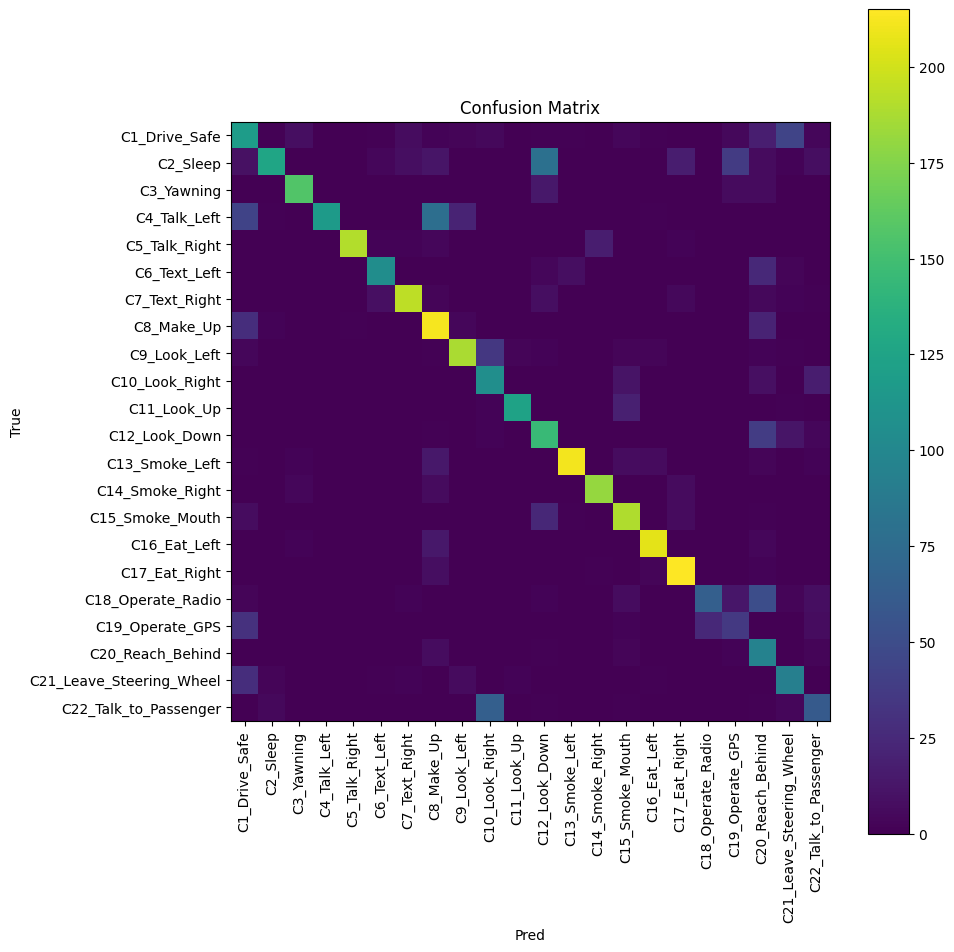

In [42]:
weights = MobileNet_V3_Large_Weights.DEFAULT
best_model = mobilenet_v3_large(weights=weights)
last_channel = best_model.classifier[-1].in_features
best_model.classifier[-1] = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(last_channel, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.6),
    nn.Linear(1280, NUM_CLASSES),
)

state_dict = torch.load(best_path, map_location=device)
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="val eval"):
        xb = xb.to(device, non_blocking=True)
        logits = best_model(xb)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=CLASS_NAMES, digits=4))

cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(10, 10))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(CLASS_NAMES)), CLASS_NAMES, rotation=90)
plt.yticks(range(len(CLASS_NAMES)), CLASS_NAMES)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()

## 12) Quick inference preview

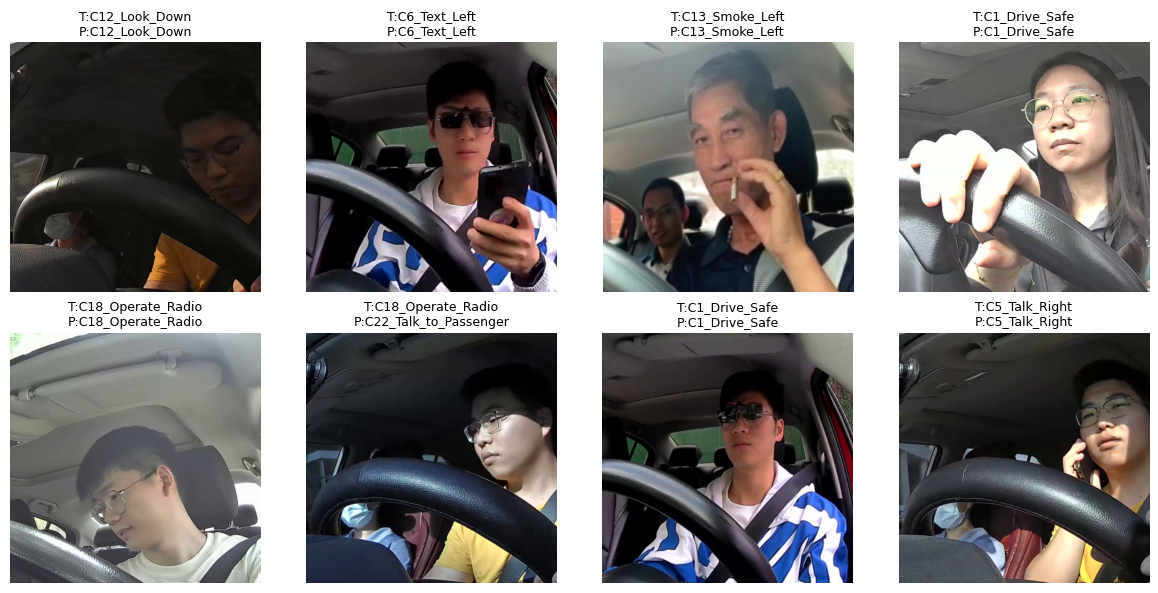

In [43]:
def denorm(x, mean, std):
    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t = torch.tensor(std).view(3, 1, 1)
    return (x * std_t) + mean_t

best_model.eval()
sample_count = min(8, len(val_ds))
sample_idx = np.random.choice(len(val_ds), size=sample_count, replace=False)
samples = [val_ds[i] for i in sample_idx]
xb = torch.stack([s[0] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(sample_count):
    ax = plt.subplot(2, math.ceil(sample_count / 2), i + 1)
    img = denorm(samples[i][0].cpu(), mean, std).clamp(0, 1)
    ax.imshow(img.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"T:{CLASS_NAMES[yb[i]]}\nP:{CLASS_NAMES[pred[i]]}", fontsize=9)
plt.tight_layout()
plt.show()